

---


# **Mushroom Identification - DINO2 Training Dataset**


---

This notebook trains on the mushroom dataset from : path = kagglehub.dataset_download("zlatan599/mushroom1"). Follow the exact same training methodology as the existing models in repos (same argumentations, loss functions, optimizer, early stopping).









---


# **0. Verify GPU**

---



In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA A100-SXM4-40GB


In [ ]:
import matplotlib.image as mpimg
import random
import matplotlib.image as mpimg
import os
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
!pip install split-folders
!pip install kagglehub



---


# **1.Clone the repo and check out banch**

---



In [ ]:
!git clone https://github.com/QuasimodoCodes/Mushrooms.git
%cd Mushrooms
!git checkout

Cloning into 'Mushrooms'...
remote: Enumerating objects: 937, done.
remote: Counting objects: 100% (285/285), done.
remote: Compressing objects: 100% (222/222), done.
remote: Total 937 (delta 107), reused 199 (delta 51), pack-reused 652 (from 2)
Receiving objects: 100% (937/937), 226.14 MiB | 18.00 MiB/s, done.
Resolving deltas: 100% (376/376), done.
Updating files: 100% (212/212), done.
/content/Mushrooms
Your branch is up to date with 'origin/master'.


In [ ]:
import kagglehub
path = kagglehub.dataset_download("zlatan599/mushroom1")

import splitfolders, shutil, os
source = f"{path}/merged_dataset"
output = "/content/Mushrooms/data/dataset_split"

splitfolders.ratio(source, output=output, seed=42, ratio=(0.8, 0.1, 0.1))
print("Done!")

Using Colab cache for faster access to the 'mushroom1' dataset.


Streaming output truncated to the last 5000 lines.
Copying files: 32935 files [05:44, 122.32 files/s]
Copying files: 32948 files [05:44, 121.63 files/s]
Copying files: 32961 files [05:44, 120.25 files/s]
Copying files: 32974 files [05:44, 120.71 files/s]
Copying files: 32987 files [05:44, 119.90 files/s]
Copying files: 33000 files [05:44, 120.92 files/s]
Copying files: 33013 files [05:44, 121.28 files/s]
Copying files: 33026 files [05:44, 121.69 files/s]
Copying files: 33039 files [05:45, 106.24 files/s]
Copying files: 33050 files [05:45, 105.03 files/s]
Copying files: 33062 files [05:45, 107.44 files/s]
Copying files: 33073 files [05:45, 100.92 files/s]
Copying files: 33085 files [05:45, 104.78 files/s]
Copying files: 33096 files [05:45, 102.42 files/s]
Copying files: 33107 files [05:45, 100.93 files/s]
Copying files: 33118 files [05:45, 101.16 files/s]
Copying files: 33129 files [05:45, 98.18 files/s] 
Copying files: 33141 files [05:46, 100.04 files/s]
Copying files: 33152 files [05:

Done!


In [ ]:
# Check if dataset_split already exists from the other notebook
import os
if os.path.exists('/content/Mushrooms/data/dataset_split'):
    print("Dataset split found!")
    for split in ['train', 'val', 'test']:
        n = sum(len(f) for _, _, f in os.walk(f'/content/Mushrooms/data/dataset_split/{split}'))
        print(f"{split}: {n:,} images")
else:
    print("NOT found — need to split again")

Dataset split found!
train: 83,202 images
val: 10,337 images
test: 10,549 images


In [ ]:
import os
print("path")
!ls

path
config.py  docs       launch.py       requirements.txt	yolo26n-cls.pt
data	   dvc_plots  prometheus.yml  scripts
deploy	   dvc.yaml   README.md       services




---


# **2. Train YOLOv10**


---



In [ ]:
import os
if os.path.exists('/content/Mushrooms/data/dataset_split'):
    print("Dataset found!")
else:
    print("Need to re-download dataset")

Dataset found!


In [ ]:
import os
os.chdir('/content/Mushrooms')

In [ ]:
!git pull origin master

From https://github.com/QuasimodoCodes/Mushrooms
 * branch            master     -> FETCH_HEAD
Already up to date.


In [ ]:
import os
with open('scripts/training/dinov2/train.py', 'r') as f:
    content = f.read()

content = content.replace(
    'from model   import build_dinov2_small',
    'from dinov2_model import build_dinov2_small'
)
content = content.replace(
    'from model import build_dinov2_small',
    'from dinov2_model import build_dinov2_small'
)

with open('scripts/training/dinov2/train.py', 'w') as f:
    f.write(content)
if os.path.exists('scripts/training/dinov2/model.py'):
    os.rename('scripts/training/dinov2/model.py',
              'scripts/training/dinov2/dinov2_model.py')
    print("Renamed model.py to dinov2_model.py")

print("Fixed!")

Renamed model.py to dinov2_model.py
Fixed!


In [ ]:
!git pull origin master
!cd scripts/training/dinov2 && python train.py --optimizer adamw --loss ce_smooth

From https://github.com/QuasimodoCodes/Mushrooms
 * branch            master     -> FETCH_HEAD
Already up to date.
  DINOv2-Small | ADAMW + CE_SMOOTH
>> GPU: NVIDIA A100-SXM4-40GB

Loading dataset from: /content/Mushrooms/data/dataset_split
>> 169 classes | 83,202 train | 10,337 val

Building DINOv2-Small (loading from facebookresearch/dinov2 hub)...
   (First run will download ~85MB weights — subsequent runs use cache)
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: x



---


# **3. Check the results and Visulization**

---



In [ ]:
import shutil
from google.colab import files
shutil.make_archive('dinov2_results', 'zip', '/content/Mushrooms/docs/franken_runs')
files.download('dinov2_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
df = pd.read_csv('/content/Mushrooms/docs/franken_runs/dinov2_adamw_ce_smooth/results.csv')
print(f"Best Top-1: {df['metrics/accuracy_top1'].max():.2f}%")
print(f"Best Top-5: {df['metrics/accuracy_top5'].max():.2f}%")
print(f"Total epochs: {len(df)}")

Best Top-1: 92.84%
Best Top-5: 98.55%
Total epochs: 49


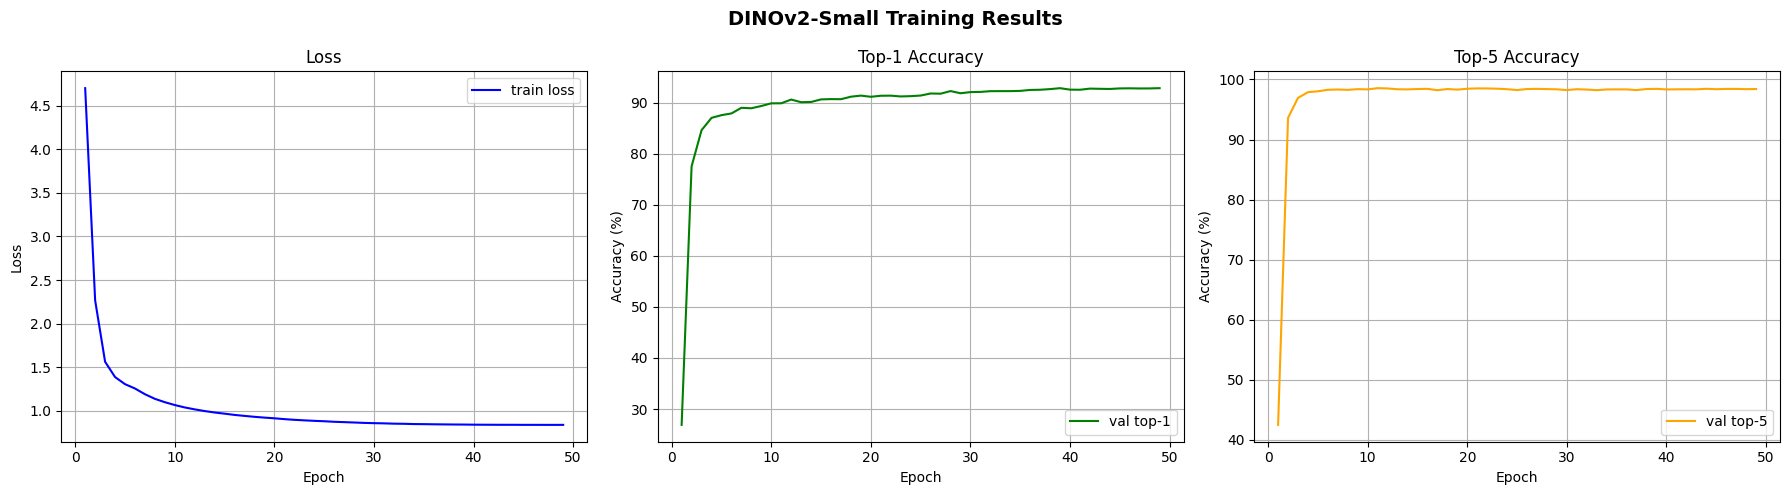

Best Top-1: 92.84%
Best Top-5: 98.55%
Total epochs: 49


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('/content/Mushrooms/docs/franken_runs/dinov2_adamw_ce_smooth/results.csv')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('DINOv2-Small Training Results', fontsize=14, fontweight='bold')

# Loss plot
axes[0].plot(df['epoch'], df['train/loss'], label='train loss', color='blue')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Top-1 Accuracy
axes[1].plot(df['epoch'], df['metrics/accuracy_top1'], label='val top-1', color='green')
axes[1].set_title('Top-1 Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)

# Top-5 Accuracy
axes[2].plot(df['epoch'], df['metrics/accuracy_top5'], label='val top-5', color='orange')
axes[2].set_title('Top-5 Accuracy')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy (%)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig('/content/Mushrooms/docs/franken_runs/dinov2_adamw_ce_smooth/training_curves.png', dpi=150)
plt.show()

print(f"Best Top-1: {df['metrics/accuracy_top1'].max():.2f}%")
print(f"Best Top-5: {df['metrics/accuracy_top5'].max():.2f}%")
print(f"Total epochs: {len(df)}")

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


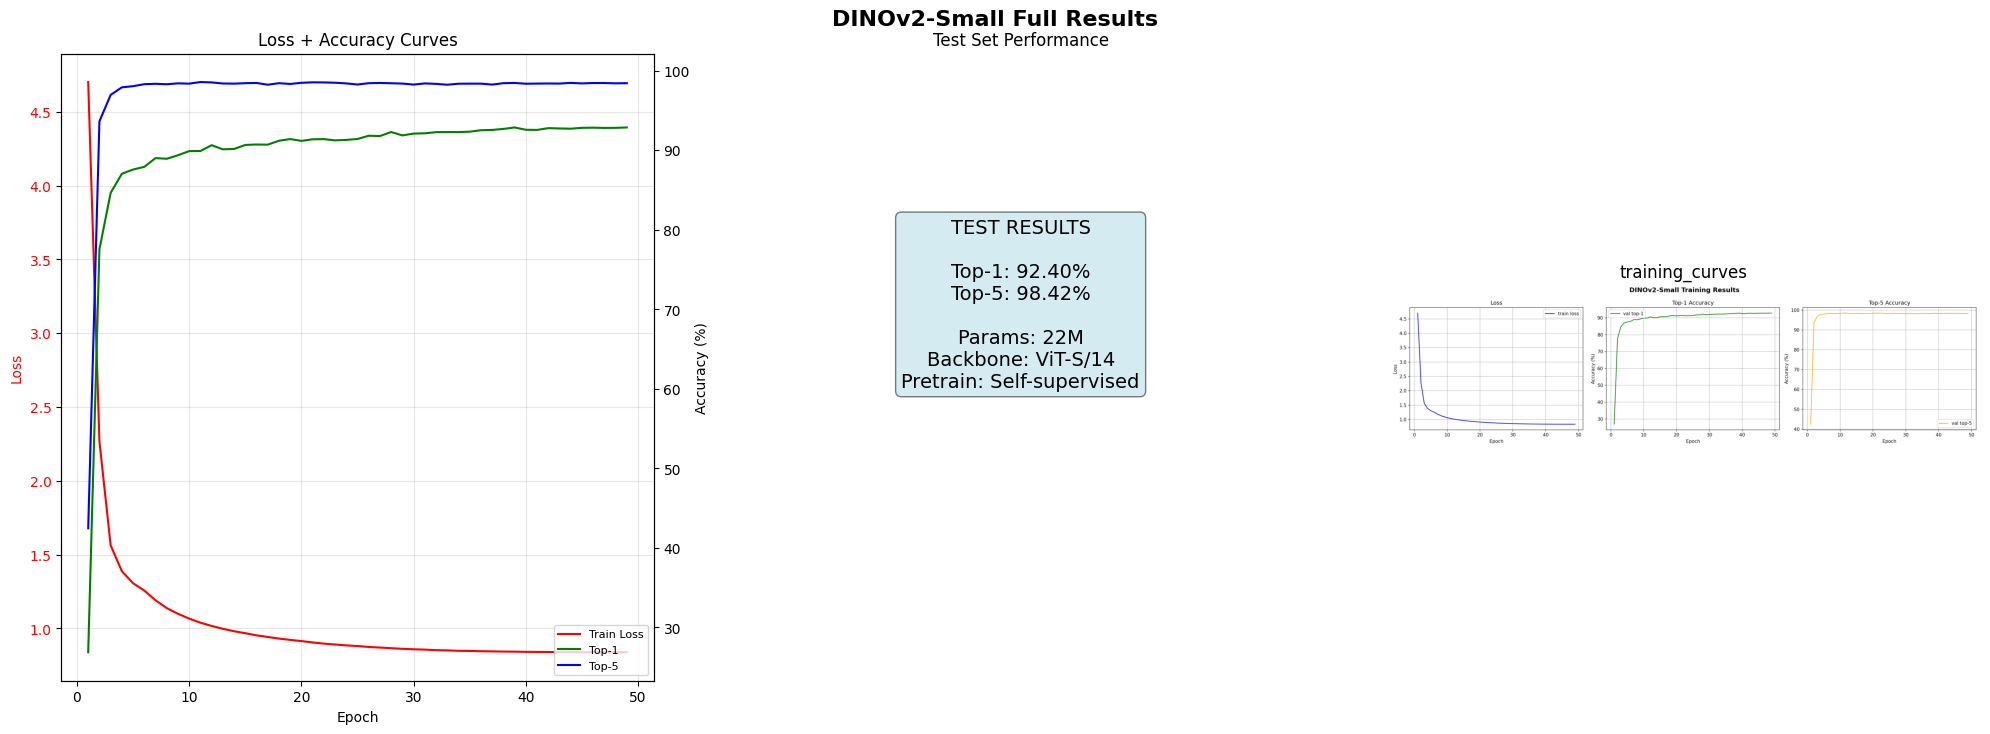


  DINOv2-Small TEST RESULTS
  Top-1 Accuracy : 92.40%
  Top-5 Accuracy : 98.42%
  Total samples  : 10,549


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import torch
import sys

sys.path.insert(0, 'scripts/training/dinov2')
from dinov2_model import build_dinov2_small
from dataset import get_dataloaders

# ── 1. Load model and test ────────────────────────────────────
device = 'cuda' if torch.cuda.is_available() else 'cpu'
_, _, test_loader, class_names = get_dataloaders('data/dataset_split', batch_size=64)

model = build_dinov2_small(num_classes=169).to(device)
model.load_state_dict(torch.load(
    'docs/franken_runs/dinov2_adamw_ce_smooth/weights/best.pt',
    map_location=device
))
model.eval()

correct_top1 = correct_top5 = total = 0
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        _, top5_pred = logits.topk(5, dim=1)
        correct_top1 += (top5_pred[:, 0] == labels).sum().item()
        correct_top5 += sum(labels[i] in top5_pred[i] for i in range(len(labels)))
        total += labels.size(0)

top1 = correct_top1 / total * 100
top5 = correct_top5 / total * 100

# ── 2. Training curves ────────────────────────────────────────
df = pd.read_csv('docs/franken_runs/dinov2_adamw_ce_smooth/results.csv')
run_dir = 'docs/franken_runs/dinov2_adamw_ce_smooth'
plot_files = [f for f in os.listdir(run_dir) if f.endswith('.png')]

# ── 3. Big figure ─────────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
fig.suptitle('DINOv2-Small Full Results', fontsize=16, fontweight='bold')

# Training curves
ax1 = fig.add_subplot(2, 3, 1)
ax2 = ax1.twinx()
ax1.plot(df['epoch'], df['train/loss'], color='red', label='Train Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='red')
ax1.tick_params(axis='y', labelcolor='red')
ax2.plot(df['epoch'], df['metrics/accuracy_top1'], color='green', label='Top-1')
ax2.plot(df['epoch'], df['metrics/accuracy_top5'], color='blue', label='Top-5')
ax2.set_ylabel('Accuracy (%)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=8)
ax1.set_title('Loss + Accuracy Curves')
ax1.grid(True, alpha=0.3)

# Test results text box
ax_text = fig.add_subplot(2, 3, 2)
ax_text.axis('off')
ax_text.text(0.5, 0.6,
    f'TEST RESULTS\n\nTop-1: {top1:.2f}%\nTop-5: {top5:.2f}%\n\nParams: 22M\nBackbone: ViT-S/14\nPretrain: Self-supervised',
    transform=ax_text.transAxes,
    fontsize=14, verticalalignment='center', horizontalalignment='center',
    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
ax_text.set_title('Test Set Performance')

# Show available plots
for i, plot_file in enumerate(plot_files[:4]):
    ax = fig.add_subplot(2, 3, i + 3)
    img = mpimg.imread(os.path.join(run_dir, plot_file))
    ax.imshow(img)
    ax.set_title(plot_file.replace('.png', ''))
    ax.axis('off')

plt.tight_layout()
plt.savefig('docs/franken_runs/dinov2_adamw_ce_smooth/full_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*40}")
print(f"  DINOv2-Small TEST RESULTS")
print(f"{'='*40}")
print(f"  Top-1 Accuracy : {top1:.2f}%")
print(f"  Top-5 Accuracy : {top5:.2f}%")
print(f"  Total samples  : {total:,}")
print(f"{'='*40}")

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


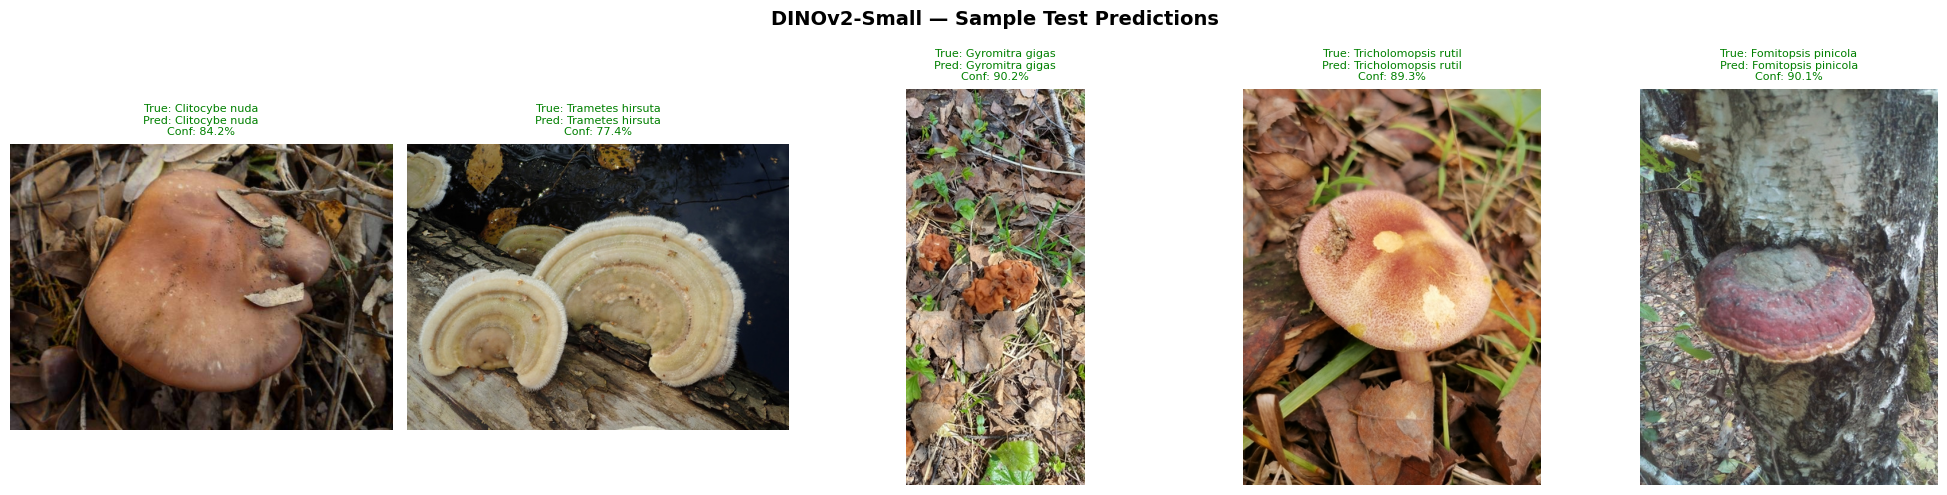

Correct: 5/5


In [ ]:
import torch
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random
import sys
from PIL import Image
from torchvision import transforms

sys.path.insert(0, 'scripts/training/dinov2')
from dinov2_model import build_dinov2_small
from dataset import get_dataloaders

# ── Load model ────────────────────────────────────────────────
device = 'cuda' if torch.cuda.is_available() else 'cpu'
_, _, test_loader, class_names = get_dataloaders('data/dataset_split', batch_size=64)

model = build_dinov2_small(num_classes=169).to(device)
model.load_state_dict(torch.load(
    'docs/franken_runs/dinov2_adamw_ce_smooth/weights/best.pt',
    map_location=device
))
model.eval()

# ── Image transform ───────────────────────────────────────────
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ── Get 5 random test images ──────────────────────────────────
test_dir = 'data/dataset_split/test'
all_images = []
for species in os.listdir(test_dir):
    species_path = os.path.join(test_dir, species)
    if os.path.isdir(species_path):
        for img_file in os.listdir(species_path):
            if img_file.endswith(('.jpg', '.jpeg', '.png')):
                all_images.append((os.path.join(species_path, img_file), species))

random.seed(42)
sample_images = random.sample(all_images, 5)

# ── Run predictions ───────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('DINOv2-Small — Sample Test Predictions', fontsize=14, fontweight='bold')

correct_count = 0
for i, (img_path, true_label) in enumerate(sample_images):
    # Load and transform image
    img_pil = Image.open(img_path).convert('RGB')
    img_tensor = transform(img_pil).unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        logits = model(img_tensor)
        probs = torch.softmax(logits, dim=1)
        top1_idx = probs.argmax(dim=1).item()
        confidence = probs[0, top1_idx].item() * 100
        pred_label = class_names[top1_idx]

    # Check correct
    is_correct = pred_label == true_label
    if is_correct:
        correct_count += 1
    color = 'green' if is_correct else 'red'

    # Display
    axes[i].imshow(img_pil)
    axes[i].axis('off')
    axes[i].set_title(
        f'True: {true_label[:20]}\nPred: {pred_label[:20]}\nConf: {confidence:.1f}%',
        fontsize=8, color=color
    )

plt.tight_layout()
plt.savefig('docs/franken_runs/dinov2_adamw_ce_smooth/sample_predictions.png', dpi=150)
plt.show()

print(f"Correct: {correct_count}/5")